# Fish Detection, Segmentation, and Centerline Extraction Pipeline

This notebook sets up the first half of the stereovision pipeline. We will:
1. Load 5 random underwater images from a local directory.
2. Use **custom YOLO weights** or **Grounding DINO** (a zero-shot text-to-bounding-box model) to detect fish using the text prompt "fish".
3. Pass those bounding boxes to **SAM (Segment Anything Model)** to generate high-precision binary masks.
4. Apply the geometric heuristic algorithm (Cheng et al., 2020) to extract head and tail keypoints from the masks.
5. Visualize the individual isolated fish with their morphological centerline.
6. Computes the 3D length using stereo reconstruction

**Prerequisites:**
Ensure you have downloaded the model weights:
* SAM: `sam_b.pt`
* Grounding DINO: `groundingdino_swint_ogc.pth`
* YOLO: `ultralytics\runs\detect\XX\best.pt` 

## 1. Environment Setup
This section imports all required mathematical, computer vision, and deep learning libraries. It also verifies that the GPU is available for hardware acceleration before loading any massive foundation models.

In [13]:
import os
import glob
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from skimage.morphology import skeletonize
from sklearn.decomposition import PCA
from collections import defaultdict
import seaborn as sns
import random
import pandas as pd
from scipy.interpolate import splprep, splev


# Custom YOLO Imports
from ultralytics import YOLO

# Segment Anything 2 Imports
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# Check Hardware
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Hardware setup complete. Using device: {DEVICE}")

Hardware setup complete. Using device: cpu


## 2. Global Configuration
All hardcoded paths, model weights, and algorithmic toggles are managed here. By centralizing these hyperparameters, the pipeline remains modular and the  mathematical functions below do not require manual editing when testing new datasets.

In [41]:
# ==========================================
# 1. PATHS & DIRECTORIES
# ==========================================
# YOLO Weights
YOLO_WEIGHTS_PATH = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\ultralytics\runs\detect\Detection_For_IS\detection_Only_training_run-with_medium_pretrained_weights\weights\best.pt"

# SAM2 Config & Weights
SAM2_CONFIG = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\weights\segmentation\segment-anything-2\sam2\configs\sam2.1\sam2.1_hiera_l.yaml" 
SAM_WEIGHTS_PATH = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\weights\segmentation\sam21_hiera_large.pt"

# Image Dataset
IMAGE_DIR = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\UMT\untouched_images_for_assessment\selected_untouched_images" 

# ==========================================
# 2. ALGORITHMIC TOGGLES & THRESHOLDS
# ==========================================
# Inference Thresholds
YOLO_CONF_THRESH = 0.25

# Image Pre-Processing Toggles
USE_CLAHE = True           # Enhances underwater contrast before passing to SAM
USE_POINT_PROMPTS = True    # Drops positive points near the snout and tail
USE_MULTI_MASK = True       # Generates 3 masks and selects the highest confidence
USE_EROSION = True          # Shaves outer pixels to tighten the mask

# Geometric NMS Filter Thresholds
IOU_THRESHOLD = 0.45        # Standard NMS overlap limit
IOMIN_THRESHOLD = 0.80      # Anti-Swallow limit (deletes large bounding boxes swallowing smaller ones)

print("Global configuration loaded.")

Global configuration loaded.


## 3. Core Mathematical Operations
This section defines the geometry steps required to translate binary masks into biological measurements. It includes the Two-Phase Area-Aware NMS Filter (to resolve bounding box fragmentation), the Hybrid Endpoint Strategy (OBB + Feret Diameter), and the Weighted Least Squares Polynomial for smooth centerline extraction.

In [42]:
# --- 1. Bounding Box Math (Two-Phase NMS) ---
def get_area(box):
    return max(0, box[2] - box[0]) * max(0, box[3] - box[1])

def calculate_overlap_metrics(boxA, boxB):
    xA, yA = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
    xB, yB = min(boxA[2], boxB[2]), min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    
    if interArea == 0: return 0.0, 0.0
    
    boxAArea = get_area(boxA)
    boxBArea = get_area(boxB)
    iou = interArea / float(boxAArea + boxBArea - interArea)
    io_min = interArea / float(min(boxAArea, boxBArea))
    return iou, io_min

def filter_overlapping_boxes(predictions, iou_threshold=IOU_THRESHOLD, iomin_threshold=IOMIN_THRESHOLD):
    """Filters overlapping boxes, heavily favoring smaller, tighter boxes (Anti-Swallow)."""
    if len(predictions) <= 1: return predictions
    
    skip_indices = set()
    # Phase 1: Anti-Swallow
    for i in range(len(predictions)):
        if i in skip_indices: continue
        boxA, areaA = predictions[i][0:4], get_area(predictions[i][0:4])
        for j in range(i + 1, len(predictions)):
            if j in skip_indices: continue
            boxB, areaB = predictions[j][0:4], get_area(predictions[j][0:4])
            iou, io_min = calculate_overlap_metrics(boxA, boxB)
            
            if io_min > iomin_threshold:
                if areaA > areaB:
                    skip_indices.add(i)
                    break
                else:
                    skip_indices.add(j)
                    
    phase_1_survivors = [predictions[i] for i in range(len(predictions)) if i not in skip_indices]
    
    # Phase 2: Standard NMS
    sorted_preds = sorted(phase_1_survivors, key=lambda x: x[4], reverse=True)
    final_preds = []
    for current in sorted_preds:
        keep = True
        for kept in final_preds:
            iou, _ = calculate_overlap_metrics(current[0:4], kept[0:4])
            if iou > iou_threshold:
                keep = False
                break
        if keep: final_preds.append(current)
        
    return final_preds

# --- 2. Length & Endpoint Extraction ---
def snap_to_mask(target_pt, mask_coords):
    distances = np.linalg.norm(mask_coords - target_pt, axis=1)
    return tuple(mask_coords[np.argmin(distances)])

def get_hybrid_length_data(binary_mask):
    """
    Calculates length and retrieves anatomical endpoints using 
    Principal Component Analysis (PCA) to find extreme projections.
    """
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, 0.0, "None", None, None
        
    largest_contour = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(largest_contour)
    box_points = np.int32(cv2.boxPoints(rect))
    
    y_idx, x_idx = np.where(binary_mask > 0)
    if len(x_idx) < 2: 
        return None, 0.0, "None", None, None
        
    points = np.column_stack((x_idx, y_idx))
    
    mean_pt = np.mean(points, axis=0)
    centered_points = points - mean_pt
    
    cov_matrix = np.cov(centered_points, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    pc1_idx = np.argmax(eigenvalues)
    primary_vector = eigenvectors[:, pc1_idx]
    
    projections = np.dot(centered_points, primary_vector)
    
    head_idx = np.argmin(projections)
    tail_idx = np.argmax(projections)
    
    pt1 = tuple(int(coord) for coord in points[head_idx])
    pt2 = tuple(int(coord) for coord in points[tail_idx])
    
    pca_length = float(np.linalg.norm(np.array(pt1) - np.array(pt2)))

    return box_points, pca_length, "PCA Extremes", pt1, pt2


# --- 3. Benchmark : Polynomial Centerline Extraction Methods ---

# METHOD 1: Skeletonization + Weighted Polynomial (Original)
def get_skeleton_centerline(binary_mask, pt1, pt2):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    smoothed_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    skeleton = skeletonize(smoothed_mask > 0)
    y_skel, x_skel = np.where(skeleton)
    if len(x_skel) < 10: return None
        
    x_data, y_data = np.append(x_skel, [pt1[0], pt2[0]]), np.append(y_skel, [pt1[1], pt2[1]])
    weights = np.append(np.ones(len(x_skel)), [10000, 10000])
    
    if abs(pt1[0] - pt2[0]) > abs(pt1[1] - pt2[1]):
        poly = np.poly1d(np.polyfit(x_data, y_data, 3, w=weights))
        x_curve = np.linspace(min(pt1[0], pt2[0]), max(pt1[0], pt2[0]), 100)
        return np.column_stack((x_curve, poly(x_curve))).astype(np.int32)
    else:
        poly = np.poly1d(np.polyfit(y_data, x_data, 3, w=weights))
        y_curve = np.linspace(min(pt1[1], pt2[1]), max(pt1[1], pt2[1]), 100)
        return np.column_stack((poly(y_curve), y_curve)).astype(np.int32)

# METHOD 2: Distance Transform + Low-Rank Polynomial
def get_dt_centerline(binary_mask):
    dist_map = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)
    y_idx, x_idx = np.where(binary_mask > 0)
    if len(x_idx) < 50: return None
    
    coords = np.column_stack((x_idx, y_idx))
    pca = PCA(n_components=2)
    pca.fit(coords)
    angle = np.arctan2(pca.components_[0, 1], pca.components_[0, 0])
    center = pca.mean_
    
    c, s = np.cos(-angle), np.sin(-angle)
    rotated_coords = np.dot(coords - center, np.array(((c, -s), (s, c))).T)
    x_rot, y_rot = rotated_coords[:, 0], rotated_coords[:, 1]
    
    num_bins = 50
    bins = np.linspace(np.min(x_rot), np.max(x_rot), num_bins)
    bin_indices = np.digitize(x_rot, bins)
    
    ridge_x, ridge_y = [], []
    for i in range(1, num_bins):
        mask_bin = bin_indices == i
        if np.any(mask_bin):
            max_d_idx = np.argmax(dist_map[y_idx[mask_bin], x_idx[mask_bin]])
            ridge_x.append(x_rot[mask_bin][max_d_idx])
            ridge_y.append(y_rot[mask_bin][max_d_idx])
            
    if len(ridge_x) < 5: return None
    
    poly = np.poly1d(np.polyfit(ridge_x, ridge_y, 3))
    x_curve_rot = np.linspace(np.min(x_rot), np.max(x_rot), 100)
    curve_rot_coords = np.column_stack((x_curve_rot, poly(x_curve_rot)))
    
    c_inv, s_inv = np.cos(angle), np.sin(angle)
    R_inv = np.array(((c_inv, -s_inv), (s_inv, c_inv)))
    return (np.dot(curve_rot_coords, R_inv.T) + center).astype(np.int32)

# METHOD 3: Parametric B-Spline via PCA and Center of Mass
def extract_centerline(binary_mask, num_points=20):
    mask_uint8 = (binary_mask * 255).astype(np.uint8)
    y_indices, x_indices = np.where(mask_uint8 > 0)
    
    if len(x_indices) < 10:
        return None 
        
    points = np.column_stack((x_indices, y_indices))
    
    mean_pt = np.mean(points, axis=0)
    centered_points = points - mean_pt
    
    cov_matrix = np.cov(centered_points, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    pc1_idx = np.argmax(eigenvalues)
    primary_vector = eigenvectors[:, pc1_idx]
    
    projections = np.dot(centered_points, primary_vector)
    
    head_idx = np.argmin(projections)
    tail_idx = np.argmax(projections)
    
    head_pt = points[head_idx]
    tail_pt = points[tail_idx]

    M = cv2.moments(mask_uint8)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = int(mean_pt[0]), int(mean_pt[1])

    x_coords = [head_pt[0], cx, tail_pt[0]]
    y_coords = [head_pt[1], cy, tail_pt[1]]
    
    unique_points = list(set(zip(x_coords, y_coords)))
    if len(unique_points) < 3:
        return np.array([[head_pt[0], head_pt[1]], [tail_pt[0], tail_pt[1]]], dtype=np.int32) 

    tck, u = splprep([x_coords, y_coords], s=0, k=2)
    u_new = np.linspace(0, 1, num_points)
    x_new, y_new = splev(u_new, tck)
    
    return np.column_stack((x_new, y_new)).astype(np.int32)

## 4. AI Pipeline Initialization
Here we load the Deep Learning models into VRAM and build the `get_fish_data` wrapper function. This function  applies inference, segmentation and length calculation in one pass.

In [43]:
# 1. Initialize YOLO
print("Loading Custom YOLO model...")
yolo_model = YOLO(YOLO_WEIGHTS_PATH)
yolo_model.to(DEVICE)

# 2. Initialize SAM2
print("Loading SAM2 model...")
sam2_model = build_sam2(SAM2_CONFIG, SAM_WEIGHTS_PATH, device=DEVICE)
sam_predictor = SAM2ImagePredictor(sam2_model)
print("Models loaded successfully!")



def get_fish_data(image_rgb, box_thresh=YOLO_CONF_THRESH): # Lowered threshold to match Script 1!
    """Master pipeline: YOLO Detection -> NMS Filter -> SAM2 Segmentation -> Geometric Extraction."""
    
    
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    
    # 1. Run YOLO (on the BGR image)
    results = yolo_model.predict(image_bgr, conf=box_thresh, verbose=False)[0]
    raw_boxes = results.boxes.data.cpu().numpy()
    
    # 2. Filter Fragmented Boxes
    filtered_boxes = filter_overlapping_boxes(raw_boxes)

    # 3. Optional CLAHE Enhancement (Operates on the RGB image)
    if USE_CLAHE:
        lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(4, 4))
        cl = clahe.apply(l)
        sam_image = cv2.cvtColor(cv2.merge((cl,a,b)), cv2.COLOR_LAB2RGB)
    else:
        sam_image = image_rgb

    # 4. SAM2 Segmentation (SAM expects RGB)
    sam_predictor.set_image(sam_image)
    fish_data = []
    
    for box_data in filtered_boxes:
        x1, y1, x2, y2 = map(int, box_data[:4])
        input_box = np.array([x1, y1, x2, y2])
        
        # Generative Point Prompts
        if USE_POINT_PROMPTS:
            center_y = (y1 + y2) / 2
            point_coords = np.array([
                [(x1 + x2) / 2, center_y],                 
                [x1 + (x2-x1)*0.1, center_y],         
                [x2 - (x2-x1)*0.1, center_y]          
            ])
            point_labels = np.array([1, 1, 1])
        else:
            point_coords, point_labels = None, None

        masks, scores, _ = sam_predictor.predict(
            box=input_box[None, :],
            point_coords=point_coords,
            point_labels=point_labels,
            multimask_output=USE_MULTI_MASK
        )
        
        chosen_mask = masks[np.argmax(scores)] if USE_MULTI_MASK else masks[0]
        binary_mask = (chosen_mask * 255).astype(np.uint8)
        
        if USE_EROSION:
            binary_mask = cv2.erode(binary_mask, np.ones((3, 3), np.uint8), iterations=1)
            
        # 5. Extract Geometry
        box_points, final_length, strategy, pt1, pt2 = get_hybrid_length_data(binary_mask)
        
        if pt1 and pt2:
            centerlines = {
                "skeleton": get_skeleton_centerline(binary_mask, pt1, pt2),
                "distance_transform": get_dt_centerline(binary_mask),
                "b_spline": extract_centerline(binary_mask)
            }
            
            fish_data.append({
                "box": [x1, y1, x2, y2],
                "mask": binary_mask,
                "keypoints": (pt1, pt2),
                "centerlines": centerlines,
                "length_px": final_length,
                "strategy": strategy
            })
            
    return fish_data, sam_image

Loading Custom YOLO model...
Loading SAM2 model...
Models loaded successfully!


## 5. Single Image Validation And Process Visualization
Before processing the full dataset, we execute the pipeline on a single image. This visualizes the final segmentation boundaries alongside the polynomial centerlines and anatomical endpoints to ensure morphological accuracy.

Macro View: Found 57 total fish in St3_75-100m(R).MOV-44.jpg
Visualizing 1 randomly selected fish.


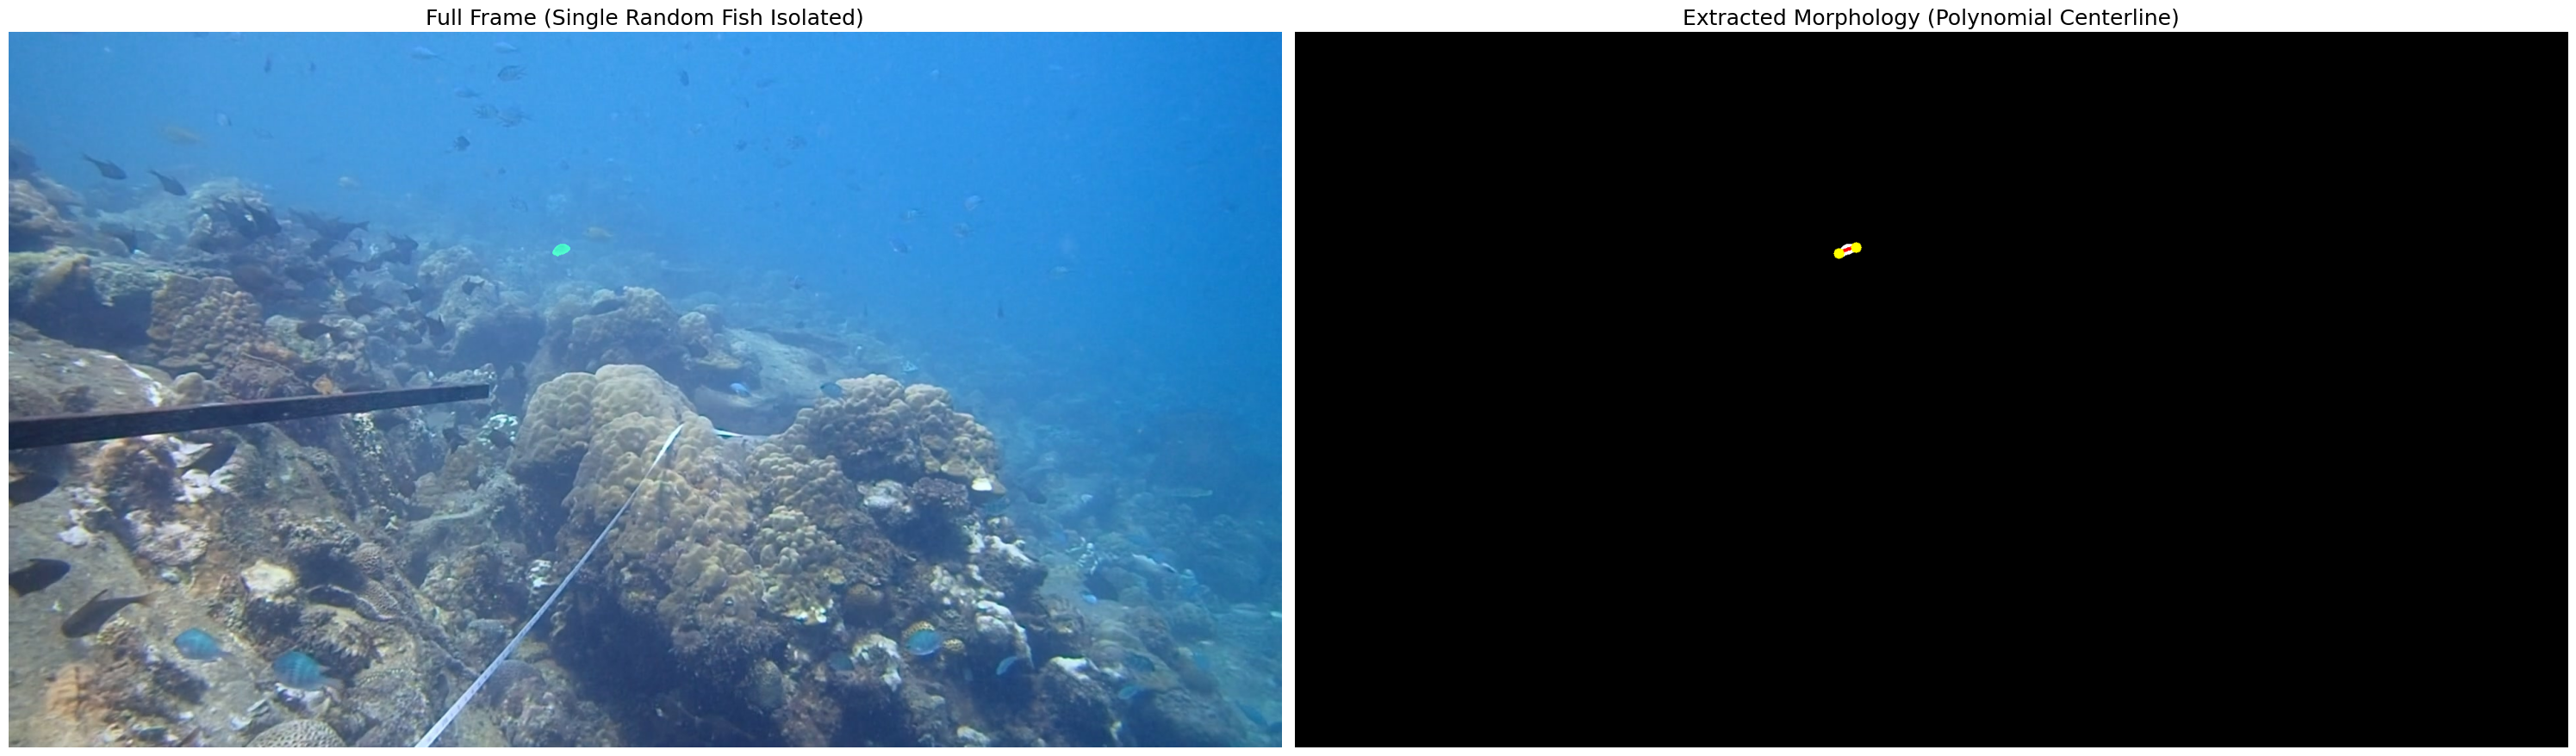

In [5]:
# Grab all images from the dataset folder
image_paths = glob.glob(os.path.join(IMAGE_DIR, "*.jpg"))

if not image_paths:
    print(f"WARNING: No images found in {IMAGE_DIR}.")
else:
    # 1. SHUFFLE THE IMAGES: This ensures we get a random frame every time we run the cell
    random.shuffle(image_paths)
    
    found_fish_image = False
    
    # Iterate through the randomly shuffled folder until we find an image with fish in it
    for test_img_path in image_paths:
        image_bgr = cv2.imread(test_img_path)
        if image_bgr is None:
            continue
            
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        # RUN THE PIPELINE 
        fish_instances, sam_image = get_fish_data(image_rgb)
        
        # If no fish are found, print a skip message and check the next random image
        if len(fish_instances) == 0:
            print(f"Skipping {os.path.basename(test_img_path)} - No fish detected.")
            continue
            
        # ==========================================
        # IF FISH ARE FOUND: ISOLATE RANDOM FISH, PLOT AND BREAK
        # ==========================================
        # 2. SELECT A RANDOM FISH from the instances detected in this frame
        target_fish = random.choice(fish_instances)
        
        print("="*60)
        print(f"Macro View: Found {len(fish_instances)} total fish in {os.path.basename(test_img_path)}")
        print("Visualizing 1 randomly selected fish.")

        full_overlay = image_rgb.copy()
        mask_layer = np.zeros_like(image_rgb)
        mask_and_keypoints = np.zeros_like(image_rgb)

        # 3. Apply visualizations ONLY to the randomly selected target_fish
        mask_boolean = target_fish["mask"] > 0
        
        # Color the mask green
        mask_layer[mask_boolean] = [0, 255, 0] 
        mask_and_keypoints[mask_boolean] = [255, 255, 255]
        
        pt1, pt2 = target_fish["keypoints"]
        
        # Select which of the 3 benchmark curves to display in the Macro-View
        centerline = target_fish["centerlines"]["skeleton"] 
        
        # Draw the smooth polynomial curve
        if centerline is not None:
            cv2.polylines(mask_and_keypoints, [centerline], isClosed=False, color=(255, 0, 0), thickness=4)
        
        # Draw the geometric endpoints
        cv2.circle(mask_and_keypoints, pt1, 8, (255, 255, 0), -1) 
        cv2.circle(mask_and_keypoints, pt2, 8, (255, 255, 0), -1)

        # Alpha blend the original image with the green mask
        blended_overlay = cv2.addWeighted(full_overlay, 1.0, mask_layer, 0.4, 0)

        # Plot the results side-by-side
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 15))
        
        ax1.imshow(blended_overlay)
        ax1.set_title("Full Frame (Single Random Fish Isolated)", fontsize=18)
        ax1.axis('off')
        
        ax2.imshow(mask_and_keypoints)
        ax2.set_title("Extracted Morphology (Polynomial Centerline)", fontsize=18)
        ax2.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        found_fish_image = True
        break # Exit the loop so we only plot ONE macro-view!
        
    if not found_fish_image:
        print("WARNING: Searched all images in the folder, but no fish were detected by the model.")

### Single Instance Pipeline Breakdown 
To clearly illustrate the methodology, this cell isolates a single detected fish and visualizes the sequential transformations applied by the pipeline. It extracts a padded crop of the region of interest (ROI) and plots the five intermediary steps: 1) The Raw Image, 2) YOLO Detection, 3) SAM-2 Segmentation, 4) Topological Thinning (Skeletonization), and 5) Cubic Polynomial Regression.

Visualizing extended pipeline breakdown for fish at coordinates: [75, 836, 213, 923]


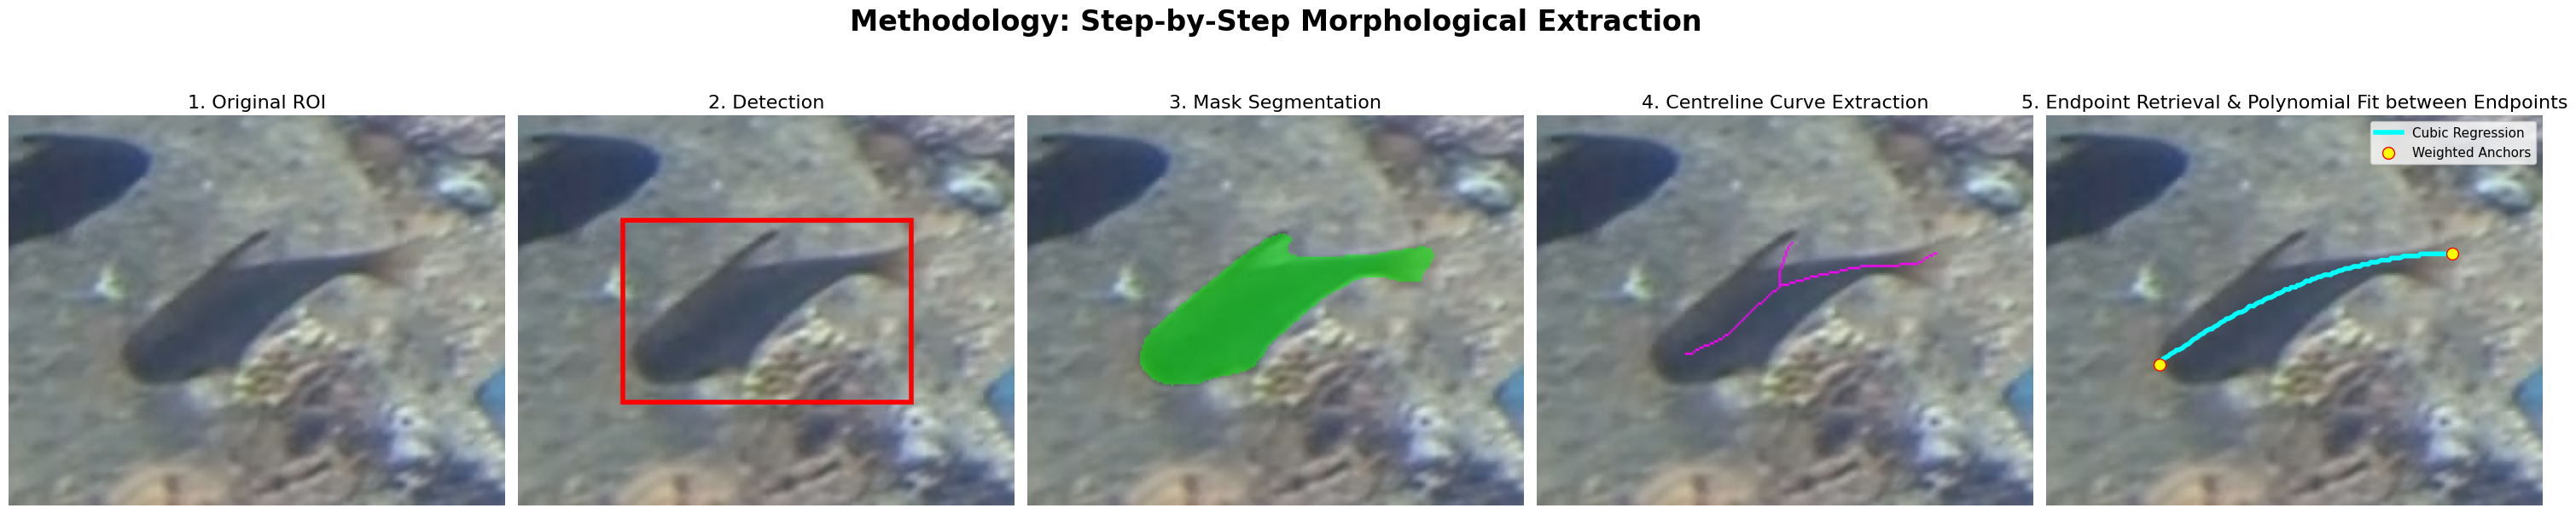

In [6]:
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from skimage.morphology import skeletonize

def plot_pipeline_stages_extended(image_rgb, fish, pad=60):
    """
    Generates a 1x5 grid showing the step-by-step pipeline transformations, 
    specifically highlighting the transition from raw skeleton to cubic regression.
    """
    # 1. Extract bounding box and add dynamic padding for a clean crop
    x1, y1, x2, y2 = fish['box']
    h, w, _ = image_rgb.shape
    
    x1_p = max(0, x1 - pad)
    y1_p = max(0, y1 - pad)
    x2_p = min(w, x2 + pad)
    y2_p = min(h, y2 + pad)
    
    crop_rgb = image_rgb[y1_p:y2_p, x1_p:x2_p].copy()
    
    # 2. Setup the Plot
    fig, axes = plt.subplots(1, 5, figsize=(30, 6))
    fig.suptitle("Methodology: Step-by-Step Morphological Extraction", fontsize=24, fontweight='bold', y=1.05)
    
    # Helper function to shift global coordinates to the local cropped coordinates
    def shift_pts(pts):
        if pts is None: return None
        shifted = pts.copy()
        shifted[:, 0] -= x1_p
        shifted[:, 1] -= y1_p
        return shifted

    # ==========================================
    # STAGE 1: Original Image
    # ==========================================
    axes[0].imshow(crop_rgb)
    axes[0].set_title("1. Original ROI", fontsize=16)

    # ==========================================
    # STAGE 2: YOLO Bounding Box
    # ==========================================
    axes[1].imshow(crop_rgb)
    rect = plt.Rectangle((x1 - x1_p, y1 - y1_p), x2 - x1, y2 - y1, 
                         fill=False, edgecolor='red', linewidth=4)
    axes[1].add_patch(rect)
    axes[1].set_title("2. Detection", fontsize=16)

    # ==========================================
    # STAGE 3: SAM-2 Segmentation
    # ==========================================
    mask_crop = fish['mask'][y1_p:y2_p, x1_p:x2_p]
    overlay = crop_rgb.copy()
    overlay[mask_crop > 0] = [0, 255, 0] # Color the mask green
    
    blended_mask = cv2.addWeighted(crop_rgb, 0.5, overlay, 0.5, 0)
    axes[2].imshow(blended_mask)
    axes[2].set_title("3. Mask Segmentation", fontsize=16)

    # ==========================================
    # STAGE 4: Raw Topological Skeleton
    # ==========================================
    # Re-calculate the skeleton on the fly for visualization
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    smoothed_mask = cv2.morphologyEx(fish['mask'], cv2.MORPH_CLOSE, kernel)
    skeleton = skeletonize(smoothed_mask > 0)
    
    # Crop the skeleton to our ROI
    skeleton_crop = skeleton[y1_p:y2_p, x1_p:x2_p]
    
    # Create an overlay painting the raw 1-pixel skeleton in bright magenta
    skel_overlay = crop_rgb.copy()
    skel_overlay[skeleton_crop] = [255, 0, 255] 
    
    axes[3].imshow(skel_overlay)
    axes[3].set_title("4. Centreline Curve Extraction", fontsize=16)

    # ==========================================
    # STAGE 5: Centerline Regularization (Cubic)
    # ==========================================
    axes[4].imshow(crop_rgb)
    
    # Grab the baseline skeleton cubic regression
    centerline = fish['centerlines']['skeleton']
    
    if centerline is not None:
        shifted_cline = shift_pts(centerline)
        axes[4].plot(shifted_cline[:, 0], shifted_cline[:, 1], 'cyan', linewidth=4, label="Cubic Regression")
        
    pt1, pt2 = fish['keypoints']
    axes[4].scatter([pt1[0]-x1_p, pt2[0]-x1_p], [pt1[1]-y1_p, pt2[1]-y1_p], 
                    c='yellow', edgecolors='red', s=100, zorder=5, label="Weighted Anchors")
    
    axes[4].set_title("5. Endpoint Retrieval & Polynomial Fit between Endpoints", fontsize=16)
    axes[4].legend(loc='upper right', fontsize=11)

    # Cleanup axes
    for ax in axes:
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION LOGIC
# ==========================================
if 'fish_instances' in locals() and len(fish_instances) > 0:
    # Grab the largest fish in the frame for the clearest visualization
    largest_fish = max(fish_instances, key=lambda f: (f['box'][2]-f['box'][0]) * (f['box'][3]-f['box'][1]))
    
    print(f"Visualizing extended pipeline breakdown for fish at coordinates: {largest_fish['box']}")
    plot_pipeline_stages_extended(image_rgb, largest_fish, pad=50)
else:
    print("No fish found. Please run Cell 5 (Macro-View) to load an image first!")

## 6. Batch Dataset Evaluation
This section executes the AI pipeline across the entire image dataset and compares the automated morphological extractions against the human-annotated Ground Truth (YOLO-Pose format). It automatically matches the AI-detected fish to the Ground Truth annotations using Bounding Box IoU, calculates the errors, and stores the geometric data for statistical analysis.

In [44]:
# ==========================================
# DIRECTORY SETUP (Update if needed)
# ==========================================
YOLO_TEST_IMAGE_DIR = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\UMT\detection+4_keypoints_pose_estimation\images\train+val"
YOLO_TEST_LABEL_DIR = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\UMT\detection+4_keypoints_pose_estimation\labels\train+val"

# YOLO_TEST_IMAGE_DIR = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\UMT\detection+4_keypoints_pose_estimation\images\val"
# YOLO_TEST_LABEL_DIR = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\UMT\detection+4_keypoints_pose_estimation\labels\val"

In [45]:
# ==========================================
# EVALUATION MATH & PARSERS
# ==========================================
def parse_yolov8_pose(txt_path, img_width, img_height):
    if not os.path.exists(txt_path): return []
    gt_fishes = []
    with open(txt_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) < 17: continue
            
            x_c, y_c, w, h = map(float, parts[1:5])
            x1, y1 = (x_c - w/2) * img_width, (y_c - h/2) * img_height
            x2, y2 = (x_c + w/2) * img_width, (y_c + h/2) * img_height
            
            kps = [[float(parts[5 + i*3]) * img_width, float(parts[6 + i*3]) * img_height] for i in range(4)]
            gt_fishes.append({"bbox": [x1, y1, x2, y2], "keypoints": np.array(kps, dtype=np.float32)})
    return gt_fishes

def calc_arc_length(curve_2d):
    return np.sum(np.linalg.norm(np.diff(curve_2d, axis=0), axis=1))

def evaluate_2d_centerline(ai_centerline, gt_keypoints):
    P0, P1, P2, P3 = gt_keypoints[0], gt_keypoints[1], gt_keypoints[2], gt_keypoints[3]
    
    # 1. Continuous Ground Truth Bézier (Keep this purely for visual plotting)
    t = np.linspace(0, 1, 100).reshape(-1, 1)
    gt_curve = ((1-t)**3 * P0 + 3 * (1-t)**2 * t * P1 + 3 * (1-t) * t**2 * P2 + t**3 * P3)
    
    # 2. Auto-Flip AI Centerline (Ensure Snout is index 0)
    if np.linalg.norm(ai_centerline[-1] - P0) < np.linalg.norm(ai_centerline[0] - P0):
        ai_centerline = ai_centerline[::-1]
        
    # 3. Crop AI Total Length down to GT Standard Length (Peduncle)
    crop_idx = np.argmin(np.linalg.norm(ai_centerline - P3, axis=1))
    ai_cropped_sl = ai_centerline[:crop_idx+1]
    
    # 4. Metrics
    # FIX: Calculate the true Ground Truth length through the actual annotated segments
    gt_sl_px = calc_arc_length(gt_keypoints) 
    
    ai_sl_px = calc_arc_length(ai_cropped_sl)
    length_error_pct = (abs(ai_sl_px - gt_sl_px) / gt_sl_px * 100) if gt_sl_px > 0 else 0.0
    snout_drift_px = np.linalg.norm(ai_cropped_sl[0] - P0)
    mean_shape_error_px = np.mean(np.min(cdist(ai_cropped_sl, gt_curve), axis=1))
    
    return {
        "length_error_pct": length_error_pct,
        "snout_drift_px": snout_drift_px,
        "shape_error_px": mean_shape_error_px,
        "gt_curve": gt_curve,
        "ai_centerline": ai_centerline,
        "ai_cropped_sl": ai_cropped_sl,
        "gt_keypoints": gt_keypoints,
        "ai_sl_px": ai_sl_px,  
        "gt_sl_px": gt_sl_px   
    }

In [46]:


# ==========================================
# BATCH EXECUTION LOOP
# ==========================================
image_paths = glob.glob(os.path.join(YOLO_TEST_IMAGE_DIR, "*.jpg"))
all_metrics = []

print(f"Starting Batch Evaluation on {len(image_paths)} images...")

for img_path in image_paths:
    filename = os.path.basename(img_path)
    stem = os.path.splitext(filename)[0]
    
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue
    h, w = img_bgr.shape[:2]
    
    # Load Ground Truth
    gt_fishes = parse_yolov8_pose(os.path.join(YOLO_TEST_LABEL_DIR, f"{stem}.txt"), w, h)
    if not gt_fishes: continue 
        
    # Run AI Pipeline
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ai_fishes, _ = get_fish_data(img_rgb)
    
    # Match and Evaluate
    for gt_fish in gt_fishes:
        best_iou, best_ai_fish = 0, None
        for ai_fish in ai_fishes:
            iou, _ = calculate_overlap_metrics(gt_fish["bbox"], ai_fish["box"])
            if iou > best_iou: best_iou, best_ai_fish = iou, ai_fish
                
        if best_iou > 0.5 and best_ai_fish is not None:
            # Evaluate all 3 methods
            for method_name, ai_curve in best_ai_fish["centerlines"].items():
                if ai_curve is not None:
                    metrics = evaluate_2d_centerline(ai_curve, gt_fish["keypoints"])
                    metrics["filename"] = filename 
                    metrics["method"] = method_name # Tag the metric with the method used!
                    all_metrics.append(metrics)

print(f"Evaluation Complete! Successfully analyzed {len(all_metrics)} matched fish.")

Starting Batch Evaluation on 211 images...
Evaluation Complete! Successfully analyzed 7292 matched fish.


## 7. Statistical Analytics & Distributions
This cell calculates the dataset-wide averages and plots the probability density distributions for the three core error metrics. By viewing the spread (Mean vs. Median), we can quantify the robustness of the automated measurement pipeline and identify the presence of outliers.

DATASET EVALUATION RESULTS (AVERAGES BY METHOD)
                     Length Error (%)  Curve Wobble (px)  Snout Drift (px)
Method                                                                    
Distance Transform              26.97               2.73              5.85
Parametric B-Spline             13.07               3.03              5.53
Skeleton + Cubic                26.91               2.93              5.71


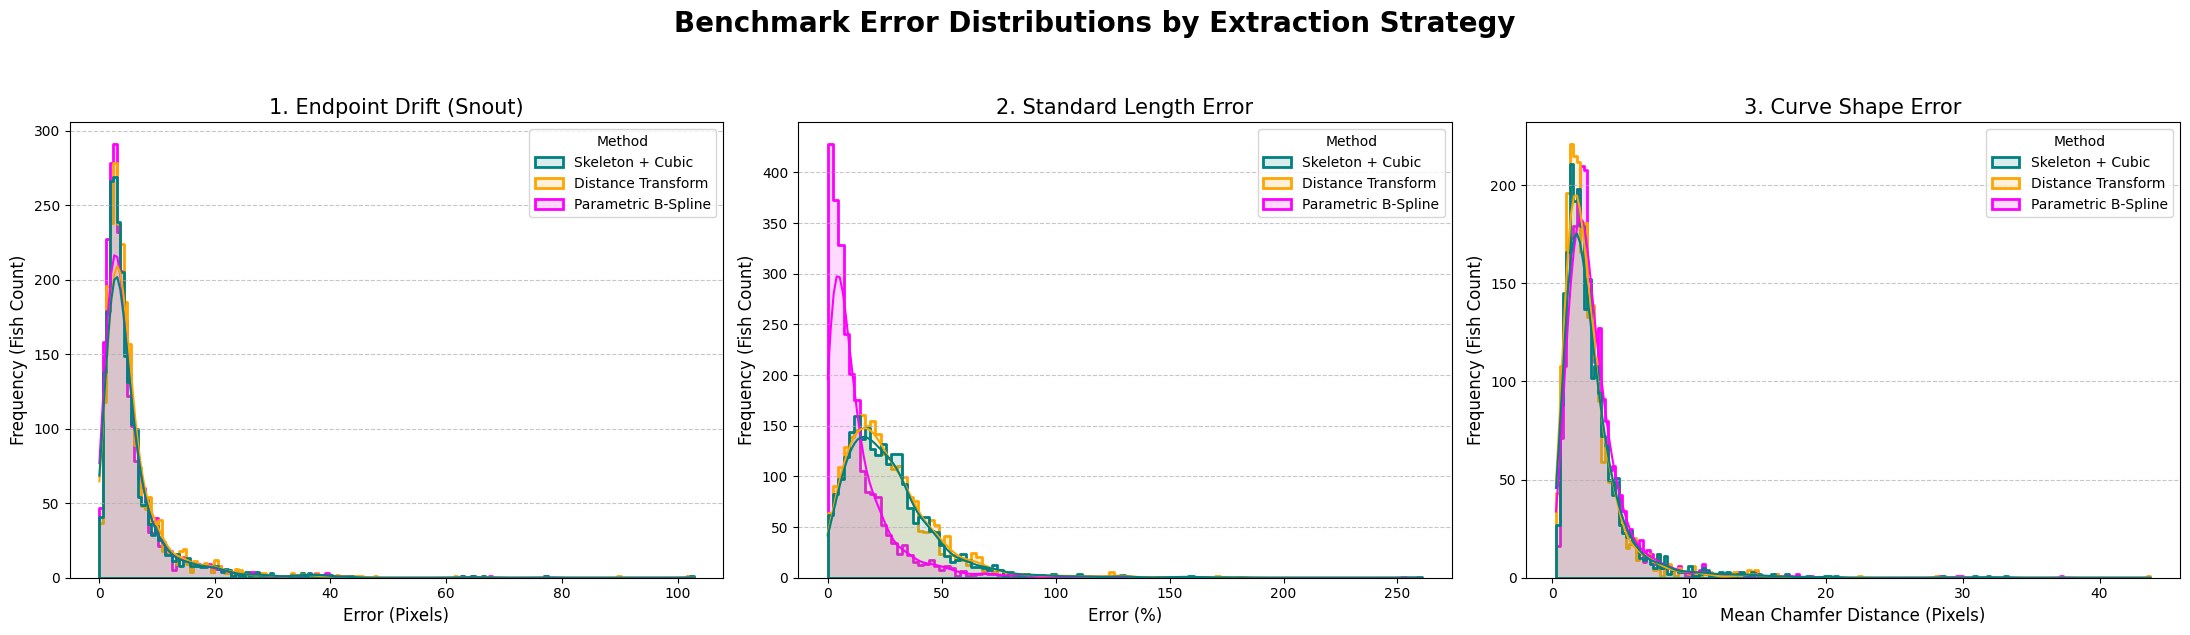

In [47]:
if len(all_metrics) > 0:
    # 1. Convert to Pandas DataFrame for advanced Seaborn plotting
    df = pd.DataFrame(all_metrics)

    # Map the internal dictionary keys to clean, report-ready names
    method_labels = {
        'skeleton': 'Skeleton + Cubic',
        'distance_transform': 'Distance Transform',
        'b_spline': 'Parametric B-Spline'
    }
    df['Method'] = df['method'].map(method_labels)

    # 2. Print Global Statistics Table
    print("="*70)
    print("DATASET EVALUATION RESULTS (AVERAGES BY METHOD)")
    print("="*70)
    
    # Group by method and calculate the mean for the 3 error types
    summary_stats = df.groupby('Method')[['length_error_pct', 'shape_error_px', 'snout_drift_px']].mean()
    
    # Rename columns for the printed table
    summary_stats.columns = ['Length Error (%)', 'Curve Wobble (px)', 'Snout Drift (px)']
    print(summary_stats.round(2).to_string())
    print("="*70)

    # 3. Plot Distributions
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle("Benchmark Error Distributions by Extraction Strategy", fontsize=20, fontweight='bold', y=1.05)

    metrics_to_plot = [
        ('snout_drift_px', '1. Endpoint Drift (Snout)', 'Error (Pixels)'),
        ('length_error_pct', '2. Standard Length Error', 'Error (%)'),
        ('shape_error_px', '3. Curve Shape Error', 'Mean Chamfer Distance (Pixels)')
    ]

    # Define consistent colors for the 3 methods
    palette = {
        'Skeleton + Cubic': 'teal', 
        # 'PCA Parabola': 'magenta', 
        'Distance Transform': 'orange',
        'Parametric B-Spline': 'magenta'
    }

    for ax, (metric, title, xlabel) in zip(axes, metrics_to_plot):
        # We use element='step' to draw the outlines of the histograms. 
        # Solid overlapping bars can hide data, but 'step' makes overlapping clear.
        sns.histplot(
            data=df,
            x=metric,
            hue='Method',
            palette=palette,
            kde=True,           # Adds the smooth trendline
            element='step',     # Removes vertical bars between bins for clarity
            alpha=0.15,         # Makes the fill highly transparent
            linewidth=2,
            ax=ax
        )
        ax.set_title(title, fontsize=15)
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel("Frequency (Fish Count)", fontsize=12)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("No metrics available to plot. Run the batch evaluation loop first.")

## 8. Qualitative Metric Visualization (Best, Average, Worst Cases)
To contextualize the statistical data, this script sorts the dataset by error magnitude and generates an auto-zoomed 3x3 grid. It displays the images that performed the best, the images that perfectly represent the dataset's mathematical average, and the worst-case failures.

In [48]:


def draw_benchmark_subplot(ax, item, img_dir, method_title):
    """
    Renders a single benchmark subplot, overlaying the AI-predicted centerline 
    and ground truth annotations onto the cropped original image.
    """
    img_path = os.path.join(img_dir, item['filename'])
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    
    # Plot AI Length vs GT Length
    ax.plot(item['ai_cropped_sl'][:, 0], item['ai_cropped_sl'][:, 1], 'cyan', linewidth=4, label="AI Centerline")
    ax.plot(item['gt_curve'][:, 0], item['gt_curve'][:, 1], 'r--', linewidth=2, label="GT Annotation")
    ax.scatter(item['gt_keypoints'][:, 0], item['gt_keypoints'][:, 1], c='yellow', edgecolors='red', s=50, zorder=5)
    
    # Dynamic Cropping: Auto-Zoom to the anatomical bounds
    all_pts = np.vstack((item['ai_centerline'], item['gt_curve']))
    pad = 60
    min_x, max_x = np.min(all_pts[:, 0]), np.max(all_pts[:, 0])
    min_y, max_y = np.min(all_pts[:, 1]), np.max(all_pts[:, 1])
    h, w, _ = img.shape
    
    ax.set_xlim(max(0, min_x - pad), min(w, max_x + pad))
    ax.set_ylim(min(h, max_y + pad), max(0, min_y - pad)) 
    
    # Formatting
    err_val = item['length_error_pct'] if 'length_error' in method_title else item.get('shape_error_px', item.get('snout_drift_px', 0))
    # We'll extract the exact current metric from the main loop to keep titles clean
    ax.axis('off')




### Selective Samples Comparison By Metrics
This strategy compares the best, average and worst cases of the skeletonization algorithm against the same samples using the other two strategies.


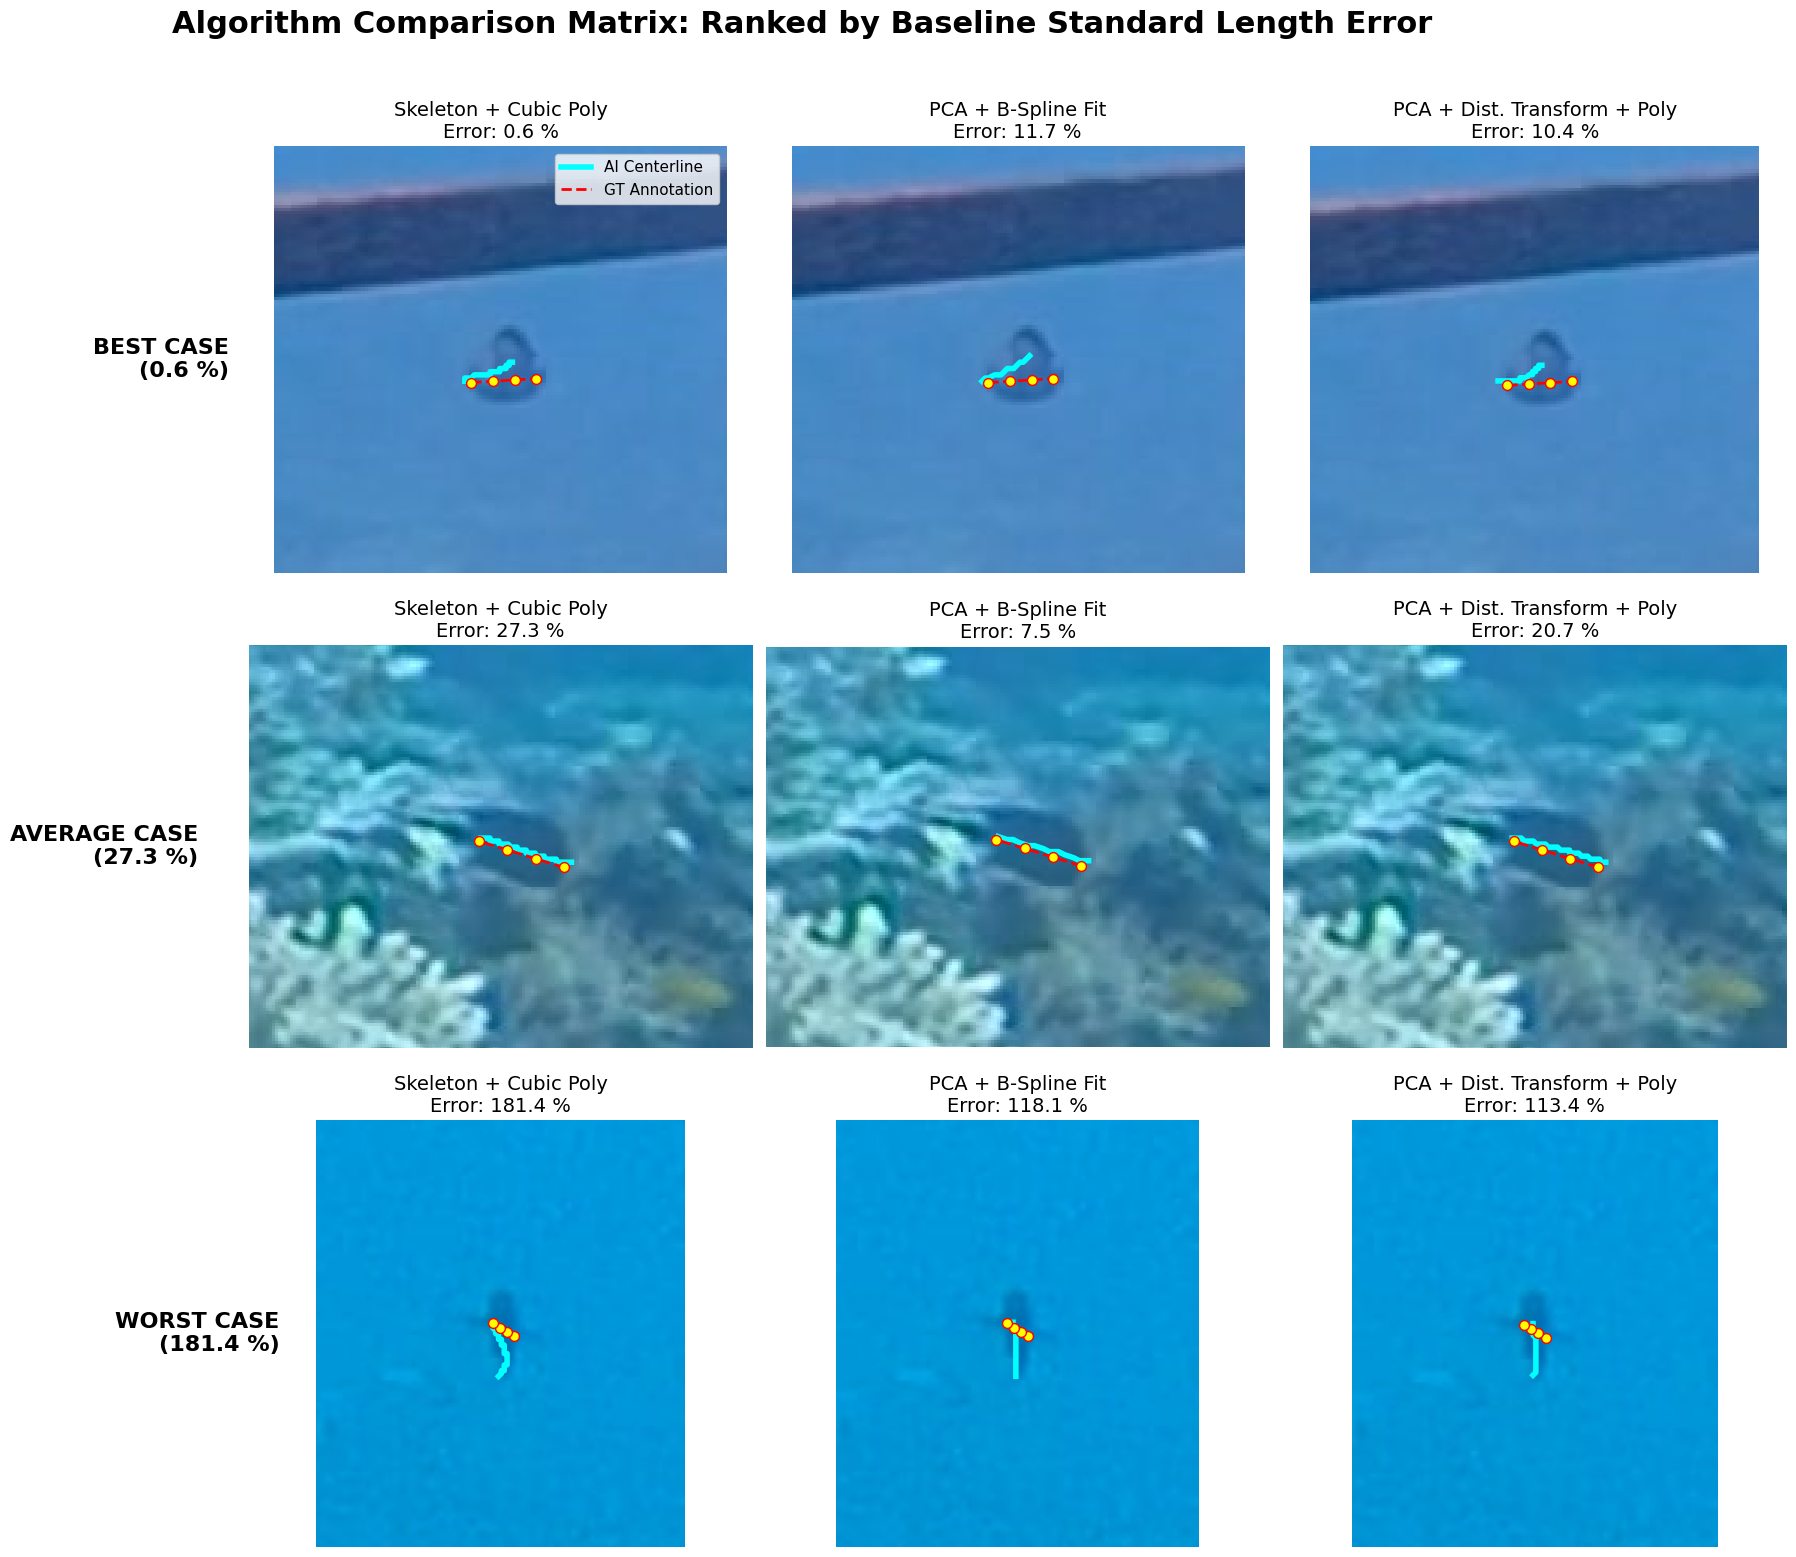


--------------------------------------------------------------------------------



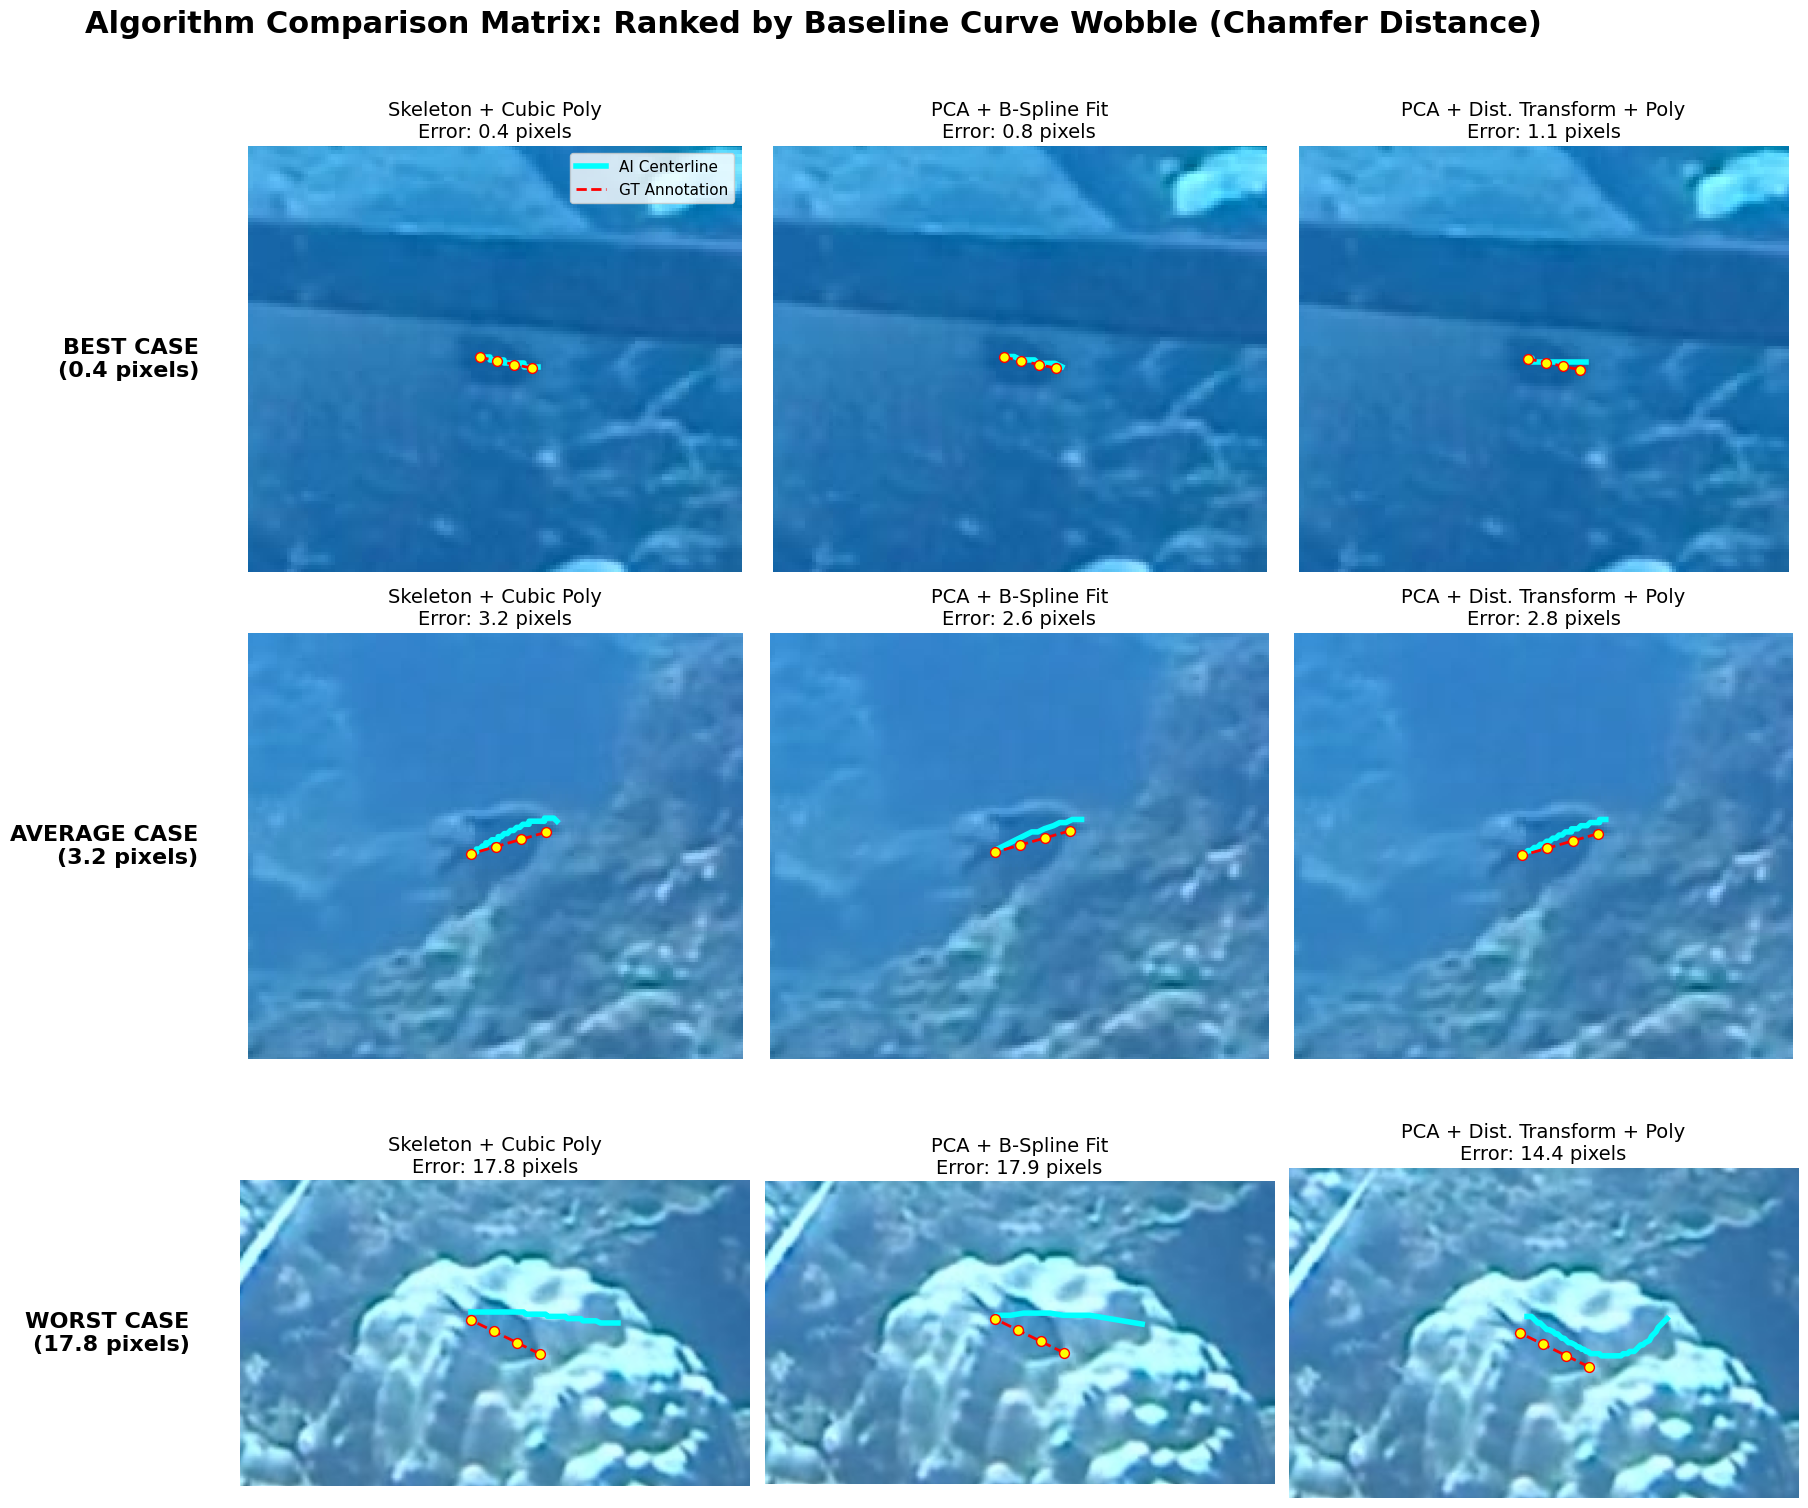


--------------------------------------------------------------------------------



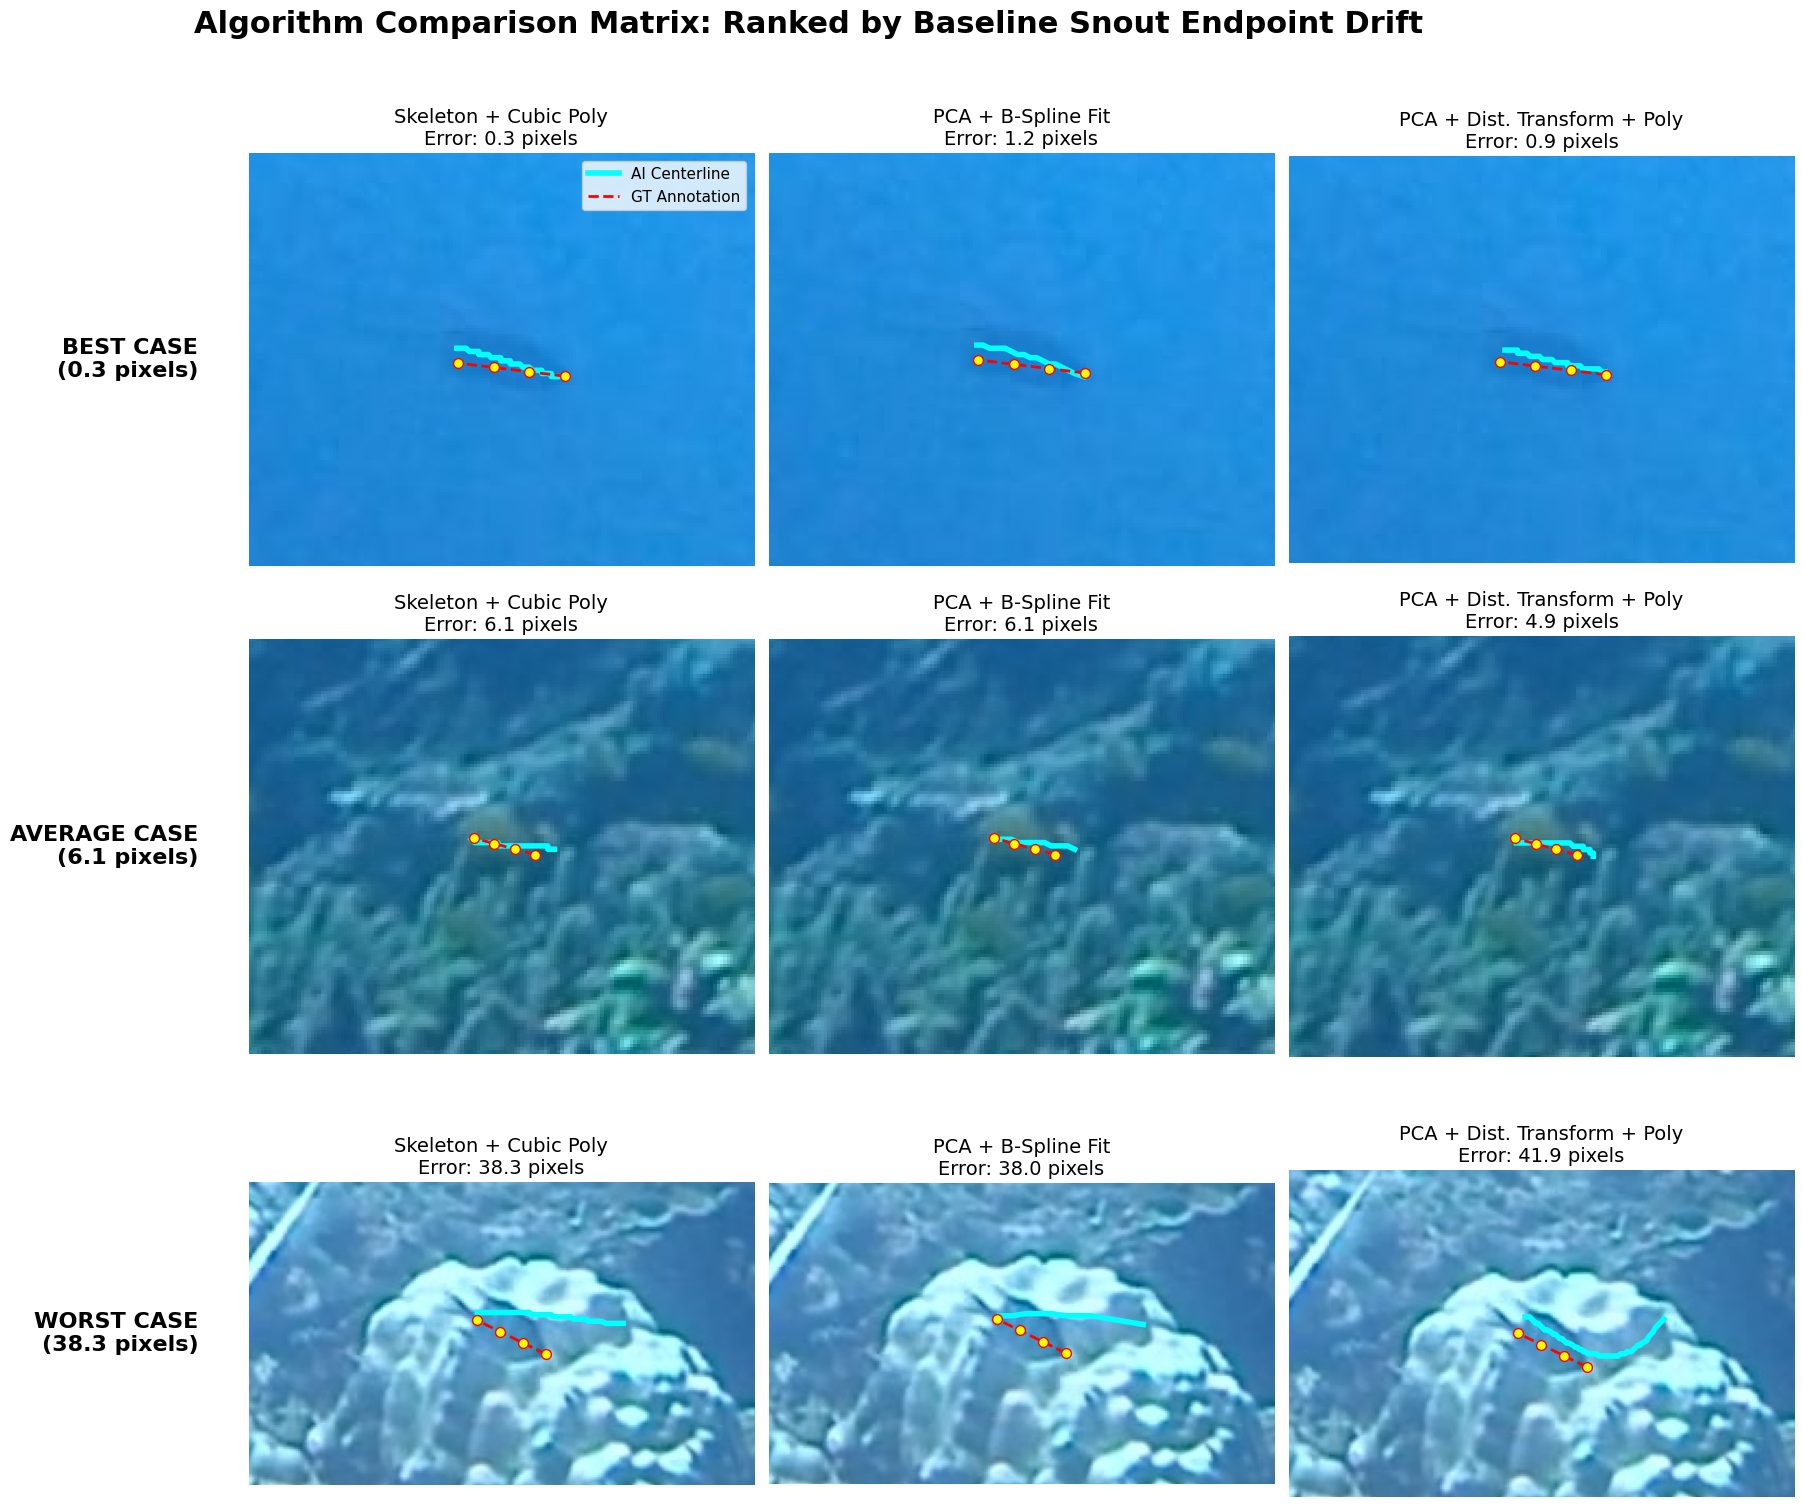


--------------------------------------------------------------------------------



In [49]:
# ==========================================
# EXECUTION LOGIC: GENERATE 3 SEPARATE PLOTS
# ==========================================
if len(all_metrics) >= 9:
    # 1. Group metrics by image filename
    grouped_metrics = defaultdict(dict)
    for m in all_metrics:
        grouped_metrics[m['filename']][m['method']] = m
        
    valid_filenames = [f for f, methods in grouped_metrics.items() if len(methods) == 3]
    
    if len(valid_filenames) >= 3:
        
        metrics_to_plot = [
            ('length_error_pct', 'Standard Length Error', '%'),
            ('shape_error_px', 'Curve Wobble (Chamfer Distance)', 'pixels'),
            ('snout_drift_px', 'Snout Endpoint Drift', 'pixels')
        ]
        
        methods_to_plot = [
            ("skeleton", "Skeleton + Cubic Poly"),
            ("b_spline", "PCA + B-Spline Fit"),
            ("distance_transform", "PCA + Dist. Transform + Poly")
        ]

        # 2. Iterate through each metric and generate a distinct 3x3 figure
        for metric_key, metric_title, metric_unit in metrics_to_plot:
            
            # Sort specimens based on the baseline (Skeleton) method's performance for THIS specific metric
            sorted_files = sorted(valid_filenames, key=lambda f: grouped_metrics[f]['skeleton'][metric_key])
            
            best_file = sorted_files[0]
            worst_file = sorted_files[-1]
            
            mean_err = np.mean([grouped_metrics[f]['skeleton'][metric_key] for f in valid_filenames])
            avg_file = min(valid_filenames, key=lambda f: abs(grouped_metrics[f]['skeleton'][metric_key] - mean_err))
            
            def format_label(rank, file):
                val = grouped_metrics[file]['skeleton'][metric_key]
                return f"{rank}\n({val:.1f} {metric_unit})"
                
            selected_images = [
                (best_file, format_label("BEST CASE", best_file)), 
                (avg_file, format_label("AVERAGE CASE", avg_file)), 
                (worst_file, format_label("WORST CASE", worst_file))
            ]
            
            # Construct the Plot Matrix for the current metric
            fig, axes = plt.subplots(3, 3, figsize=(20, 16))
            fig.suptitle(f"Algorithm Comparison Matrix: Ranked by Baseline {metric_title}", fontsize=22, fontweight='bold', y=0.97)

            for row_idx, (filename, row_title) in enumerate(selected_images):
                # Apply row labels to the leftmost axis
                axes[row_idx, 0].text(-0.1, 0.5, row_title, transform=axes[row_idx, 0].transAxes, 
                                      fontsize=16, fontweight='bold', va='center', ha='right', rotation=0)
                
                for col_idx, (method_key, method_name) in enumerate(methods_to_plot):
                    item = grouped_metrics[filename][method_key]
                    
                    # Draw the subplot
                    draw_benchmark_subplot(axes[row_idx, col_idx], item, YOLO_TEST_IMAGE_DIR, method_name)
                    
                    # Add specific error value to subplot title
                    current_error = item[metric_key]
                    axes[row_idx, col_idx].set_title(f"{method_name}\nError: {current_error:.1f} {metric_unit}", fontsize=14)
                    
                    # Apply legend strictly to the top-left subplot
                    if row_idx == 0 and col_idx == 0:
                        axes[row_idx, col_idx].legend(loc='upper right', fontsize=11)

            plt.tight_layout(rect=[0.1, 0, 1, 0.95]) 
            plt.show() # Output the complete figure for this metric, then loop to the next one!
            print("\n" + "-"*80 + "\n") # Visual separator in the notebook
            
    else:
        print("Insufficient validation data: Not enough images successfully processed all three methods.")
else:
    print("Insufficient global data: Run the batch evaluation loop prior to generating the matrix.")

### Independent Strategy Extremes (Success & Failure Analysis)
Unlike the paired comparison matrix, this cell evaluates each centerline extraction strategy entirely on its own merits. For each algorithm, it extracts the 9 Best, 9 Average, and 9 Worst cases across the three primary error metrics (Standard Length, Curve Wobble, and Snout Drift). This isolated visualization allows us to identify the specific anatomical conditions (e.g., high curvature, occlusions) where each mathematical approach excels or geometrically collapses.

In [50]:

def draw_independent_subplot(ax, item, img_dir, metric_key, metric_unit):
    """Renders a cropped subplot for a specific fish and specific error metric."""
    img_path = os.path.join(img_dir, item['filename'])
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    
    # Plot curves
    ax.plot(item['ai_cropped_sl'][:, 0], item['ai_cropped_sl'][:, 1], 'cyan', linewidth=4, label="AI Centerline")
    ax.plot(item['gt_curve'][:, 0], item['gt_curve'][:, 1], 'r--', linewidth=2, label="GT Annotation")
    ax.scatter(item['gt_keypoints'][:, 0], item['gt_keypoints'][:, 1], c='yellow', edgecolors='red', s=50, zorder=5)
    
    # Auto-Zoom
    all_pts = np.vstack((item['ai_centerline'], item['gt_curve']))
    pad = 60
    min_x, max_x = np.min(all_pts[:, 0]), np.max(all_pts[:, 0])
    min_y, max_y = np.min(all_pts[:, 1]), np.max(all_pts[:, 1])
    h, w, _ = img.shape
    
    ax.set_xlim(max(0, min_x - pad), min(w, max_x + pad))
    ax.set_ylim(min(h, max_y + pad), max(0, min_y - pad)) 
    
    # Formatting
    err_val = item[metric_key]
    ax.set_title(f"{item['filename']}\nError: {err_val:.2f} {metric_unit}", fontsize=13)
    ax.axis('off')
    
# Helper function to plot the 3x3 grids for this strategy
def plot_tier_grid(tier_rows, tier_label):
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle(f"{method_name} | {tier_label} CASES", fontsize=22, fontweight='bold', y=0.98, color='darkblue')
    
    for row_idx, (metric_key, metric_title, metric_unit) in enumerate(metrics_to_analyze):
        # Row Header on the left
        axes[row_idx, 0].text(-0.15, 0.5, f"Ranked by:\n{metric_title}", transform=axes[row_idx, 0].transAxes, 
                                fontsize=15, fontweight='bold', va='center', ha='right', rotation=0)
                                
        for col_idx in range(3):
            item = tier_rows[row_idx][col_idx]
            draw_independent_subplot(axes[row_idx, col_idx], item, YOLO_TEST_IMAGE_DIR, metric_key, metric_unit)
            
            if row_idx == 0 and col_idx == 0:
                axes[row_idx, col_idx].legend(loc='upper right', fontsize=11)
                
    plt.tight_layout(rect=[0.12, 0, 1, 0.95]) 
    plt.show()


ANALYZING STRATEGY: SKELETON + CUBIC POLY


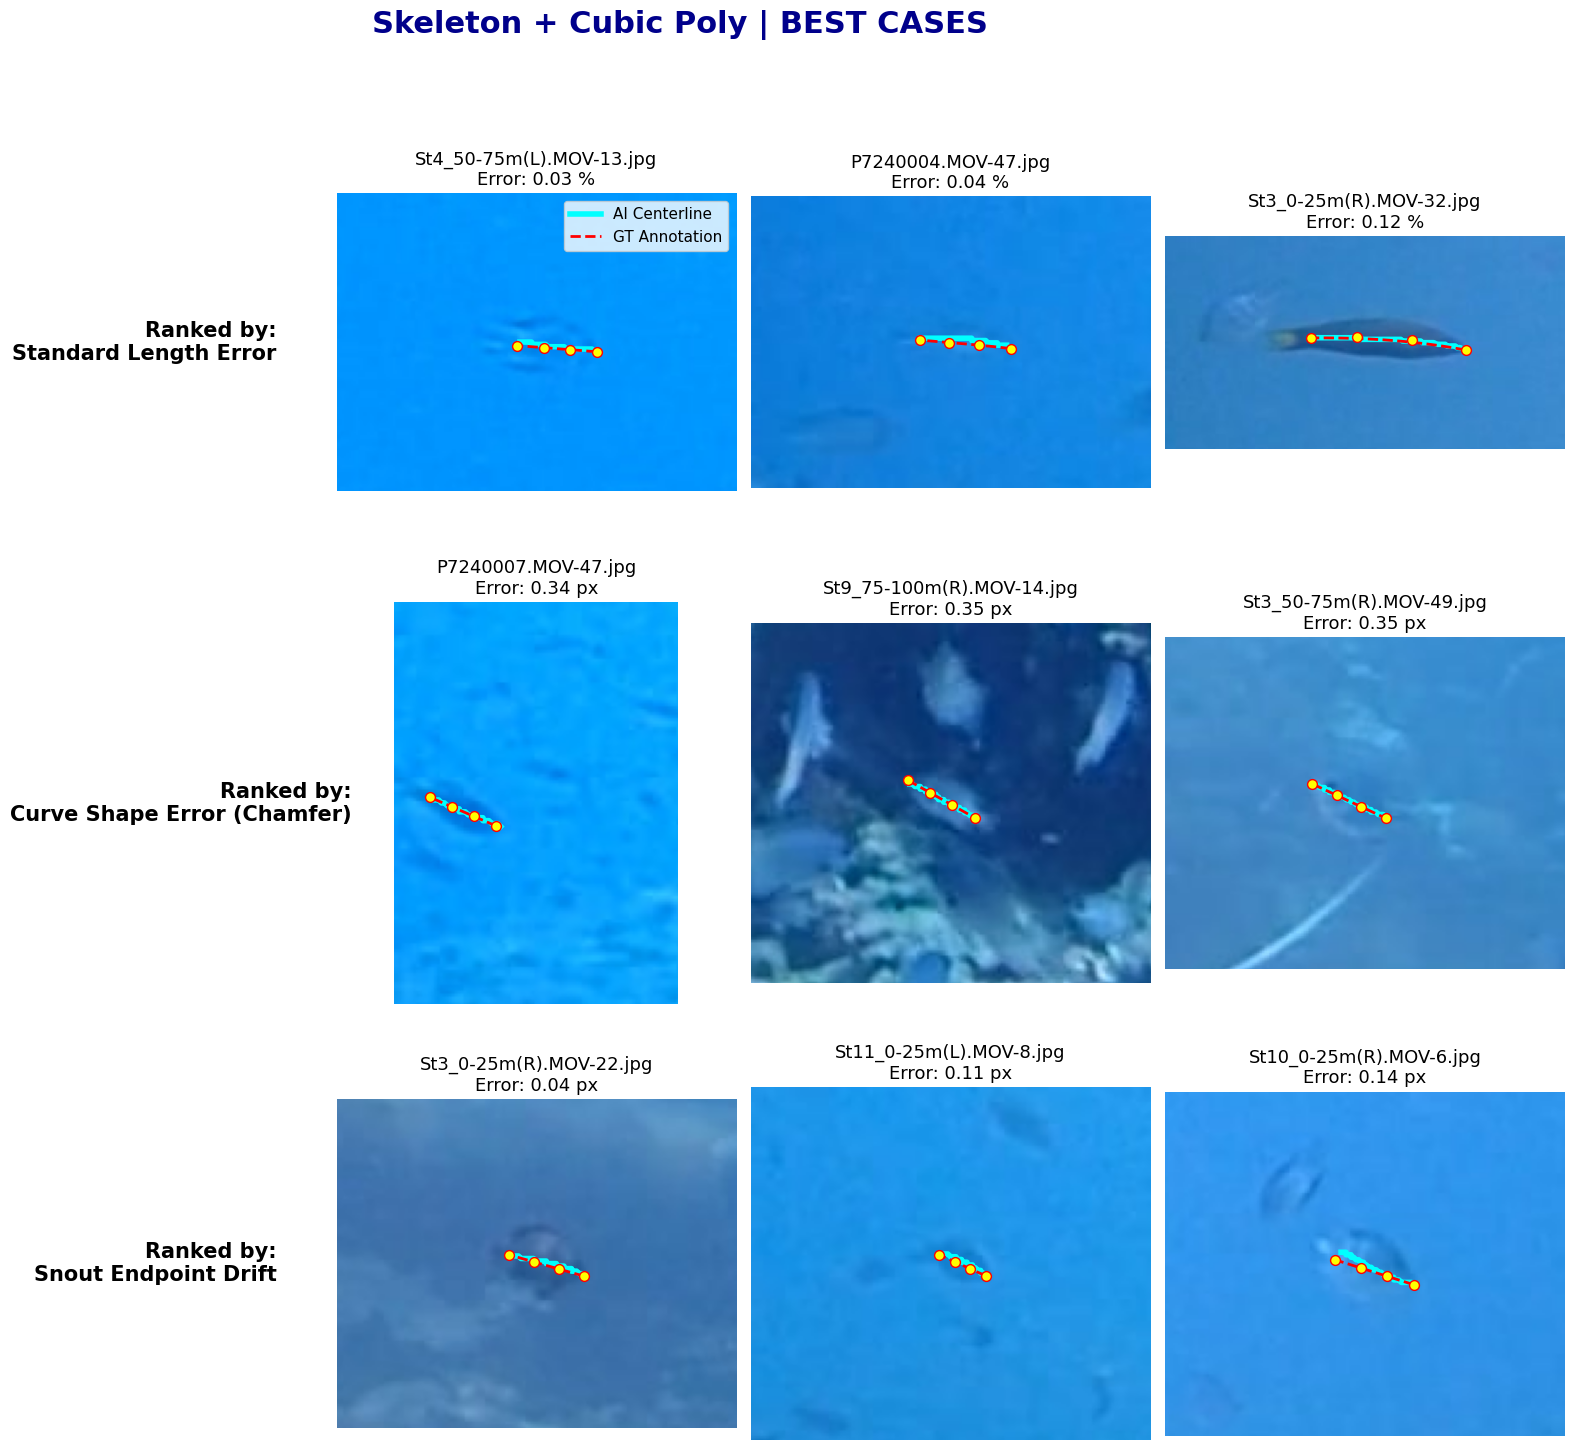

In [ ]:
# ==========================================
# EXECUTION LOGIC
# ==========================================
if len(all_metrics) > 0:
    # --- CONFIGURE NUMBER OF COLUMNS HERE ---
    NUM_COLS = 3  # Change this to plot more/fewer samples per metric!
    # ----------------------------------------
    
    methods_to_analyze = [
        ("skeleton", "Skeleton + Cubic Poly"),
        ("b_spline", "PCA + B-Spline Fit"),
        ("distance_transform", "PCA + Dist. Transform + Poly")
    ]
    
    metrics_to_analyze = [
        ('length_error_pct', 'Standard Length Error', '%'),
        ('shape_error_px', 'Curve Shape Error (Chamfer)', 'px'),
        ('snout_drift_px', 'Snout Endpoint Drift', 'px')
    ]

    for method_key, method_name in methods_to_analyze:
        # Isolate the data for ONLY this strategy
        method_data = [m for m in all_metrics if m['method'] == method_key]
        
        if len(method_data) < NUM_COLS:
            print(f"Skipping {method_name}: Not enough data ({len(method_data)} found, need {NUM_COLS}).")
            continue
            
        best_rows, avg_rows, worst_rows = [], [], []
        
        # Sort data independently for each of the 3 metrics
        for metric_key, metric_title, metric_unit in metrics_to_analyze:
            sorted_data = sorted(method_data, key=lambda x: x[metric_key])
            
            # Extract dynamically based on NUM_COLS
            best_rows.append(sorted_data[:NUM_COLS])
            worst_rows.append(sorted_data[-NUM_COLS:][::-1])
            
            # Average cases for this metric
            mean_val = np.mean([x[metric_key] for x in method_data])
            avg_sorted = sorted(method_data, key=lambda x: abs(x[metric_key] - mean_val))
            avg_rows.append(avg_sorted[:NUM_COLS])
            
        # Helper function updated to handle dynamic columns
        def plot_tier_grid(tier_rows, tier_label):
            # Dynamically adjust figure width based on the number of columns (approx 6 inches per col)
            fig_width = 6 * NUM_COLS
            fig, axes = plt.subplots(3, NUM_COLS, figsize=(fig_width, 15))
            fig.suptitle(f"{method_name} | {tier_label} CASES", fontsize=22, fontweight='bold', y=0.98, color='darkblue')
            
            for row_idx, (metric_key, metric_title, metric_unit) in enumerate(metrics_to_analyze):
                # Row Header on the far left
                axes[row_idx, 0].text(-0.15, 0.5, f"Ranked by:\n{metric_title}", transform=axes[row_idx, 0].transAxes, 
                                      fontsize=15, fontweight='bold', va='center', ha='right', rotation=0)
                                      
                for col_idx in range(NUM_COLS):
                    item = tier_rows[row_idx][col_idx]
                    draw_independent_subplot(axes[row_idx, col_idx], item, YOLO_TEST_IMAGE_DIR, metric_key, metric_unit)
                    
                    if row_idx == 0 and col_idx == 0:
                        axes[row_idx, col_idx].legend(loc='upper right', fontsize=11)
                        
            plt.tight_layout(rect=[0.12, 0, 1, 0.95]) 
            plt.show()

        # Generate the Output for the Current Strategy
        print("\n" + "="*80)
        print(f"ANALYZING STRATEGY: {method_name.upper()}")
        print("="*80)
        
        plot_tier_grid(best_rows, "BEST")
        plot_tier_grid(avg_rows, "AVERAGE")
        plot_tier_grid(worst_rows, "WORST")

else:
    print("No global data found. Run the batch evaluation loop first.")

## 9. Data Export & Pipeline Hand-off
To transition from 2D Instance Segmentation to the 3D Stereovision pipeline, we must serialize our geometric outputs. This cell compiles the core evaluation metrics, dataset statistics, and the raw 2D pixel coordinates of the anatomical keypoints into a structured CSV file for external analysis and downstream 3D triangulation.

In [ ]:
import pandas as pd
from datetime import datetime

if len(all_metrics) > 0:
    # 1. Prepare an output directory
    OUTPUT_DIR = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\outputs"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # 2. Extract the flat data into a list of dictionaries
    export_data = []
    for m in all_metrics:
        # Extract the Snout and Tail Peduncle coordinates for the Stereovision pipeline
        snout_x, snout_y = m['ai_cropped_sl'][0]
        tail_x, tail_y = m['ai_cropped_sl'][-1]
        
        export_data.append({
            "Filename": m['filename'],
            "SL_Error_Pct": round(m['length_error_pct'], 2),
            "Snout_Drift_px": round(m['snout_drift_px'], 2),
            "Shape_Wobble_px": round(m['shape_error_px'], 2),
            "AI_Snout_X": round(snout_x, 1),
            "AI_Snout_Y": round(snout_y, 1),
            "AI_Peduncle_X": round(tail_x, 1),
            "AI_Peduncle_Y": round(tail_y, 1)
        })
        
    # 3. Convert to a Pandas DataFrame
    df = pd.DataFrame(export_data)
    
    # 4. Save to CSV with a timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    csv_filename = f"detection_segmentation_pipeline_results_{timestamp}.csv"
    csv_path = os.path.join(OUTPUT_DIR, csv_filename)
    
    df.to_csv(csv_path, index=False)
    
    print("="*60)
    print("PIPELINE COMPLETE & DATA EXPORTED")
    print("="*60)
    print(f"Successfully saved records for {len(df)} fish.")
    print(f"Location: {csv_path}")
    print("\nNext Step: Load this CSV into your Stereovision Notebook to triangulate the 3D coordinates!")
else:
    print("No data available to export. Run the batch evaluation loop first.")

PIPELINE COMPLETE & DATA EXPORTED
Successfully saved records for 7292 fish.
Location: C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\outputs\detection_segmentation_pipeline_results_20260812_1708.csv

Next Step: Load this CSV into your Stereovision Notebook to triangulate the 3D coordinates!
